In [1]:
# Cell 1: Imports & Settings

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Paths
DATA_PATH = Path("../data/processed/orders_clean.csv")
OUTPUT_DIR = Path("../visuals/charts_from_notebook")

# Make sure folder exists
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data path: {DATA_PATH.resolve()}")
print(f"Charts will be saved to: {OUTPUT_DIR.resolve()}")


Data path: C:\Users\Charan\Music\PERSONAL\Github_Projects\Daxwell-SupplyChain-Analytics\data\processed\orders_clean.csv
Charts will be saved to: C:\Users\Charan\Music\PERSONAL\Github_Projects\Daxwell-SupplyChain-Analytics\visuals\charts_from_notebook


In [2]:
# Cell 2: Load processed orders data

orders_df = pd.read_csv(DATA_PATH)

# Parse date columns
orders_df["order_date"] = pd.to_datetime(orders_df["order_date"], errors="coerce")
orders_df["expected_ship_date"] = pd.to_datetime(orders_df["expected_ship_date"], errors="coerce")
orders_df["actual_ship_date"] = pd.to_datetime(orders_df["actual_ship_date"], errors="coerce")

print("Shape:", orders_df.shape)
orders_df.head()


Shape: (30000, 18)


,order_id,order_date,sku,quantity_ordered,unit_price,customer_region,order_status,fulfillment_center,expected_ship_date,actual_ship_date,priority_flag,order_value,shipping_delay_days,is_high_priority,is_cancelled,is_returned,is_completed,is_shipping_delayed
0,ORD-500000,2024-01-01,SKU-10327,39,120.50,West,Completed,FC-06,2024-01-04,2024-01-06,Normal,4699.50,2.0,False,False,False,True,True
1,ORD-500001,2024-01-01,SKU-10114,21,27.62,West,Completed,FC-06,2024-01-04,2024-01-05,Normal,580.02,1.0,False,False,False,True,True
2,ORD-500002,2024-01-01,SKU-10279,11,71.59,Northeast,Completed,FC-01,2024-01-06,2024-01-08,High,787.49,2.0,True,False,False,True,True
3,ORD-500003,2024-01-01,SKU-10111,40,107.67,West,Completed,FC-05,2024-01-06,2024-01-06,Normal,4306.80,0.0,False,False,False,True,False
4,ORD-500004,2024-01-01,SKU-10332,24,125.70,Northeast,Cancelled,FC-02,2024-01-03,NaT,Normal,3016.80,NaN,False,True,False,False,False


In [3]:
# Cell 3: Overview / Dtypes / Null counts
display(orders_df.describe(include="all").T)

print("\nNull counts:")
orders_df.isnull().sum()


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_id,30000,30000,ORD-529999,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,30000,NaN,NaN,NaN,2024-01-15 12:00:00.000000256,2024-01-01 00:00:00,2024-01-08 00:00:00,2024-01-15 12:00:00,2024-01-23 00:00:00,2024-01-30 00:00:00,NaN
sku,30000,500,SKU-10237,84,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quantity_ordered,30000.0,NaN,NaN,NaN,25.005567,1.0,13.0,25.0,37.0,49.0,14.115551
unit_price,30000.0,NaN,NaN,NaN,77.565567,5.0,41.64,77.61,113.7125,150.0,41.862011
customer_region,30000,4,West,7616,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_status,30000,3,Completed,17914,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fulfillment_center,30000,6,FC-03,5048,NaN,NaN,NaN,NaN,NaN,NaN,NaN
expected_ship_date,30000,NaN,NaN,NaN,2024-01-18 11:55:43.680000,2024-01-02 00:00:00,2024-01-11 00:00:00,2024-01-18 00:00:00,2024-01-26 00:00:00,2024-02-04 00:00:00,NaN
actual_ship_date,17914,NaN,NaN,NaN,2024-01-18 23:22:22.815674880,2024-01-01 00:00:00,2024-01-11 00:00:00,2024-01-19 00:00:00,2024-01-27 00:00:00,2024-02-06 00:00:00,NaN



Null counts:


order_id                   0
order_date                 0
sku                        0
quantity_ordered           0
unit_price                 0
customer_region            0
order_status               0
fulfillment_center         0
expected_ship_date         0
actual_ship_date       12086
priority_flag              0
order_value                0
shipping_delay_days    12086
is_high_priority           0
is_cancelled               0
is_returned                0
is_completed               0
is_shipping_delayed        0
dtype: int64

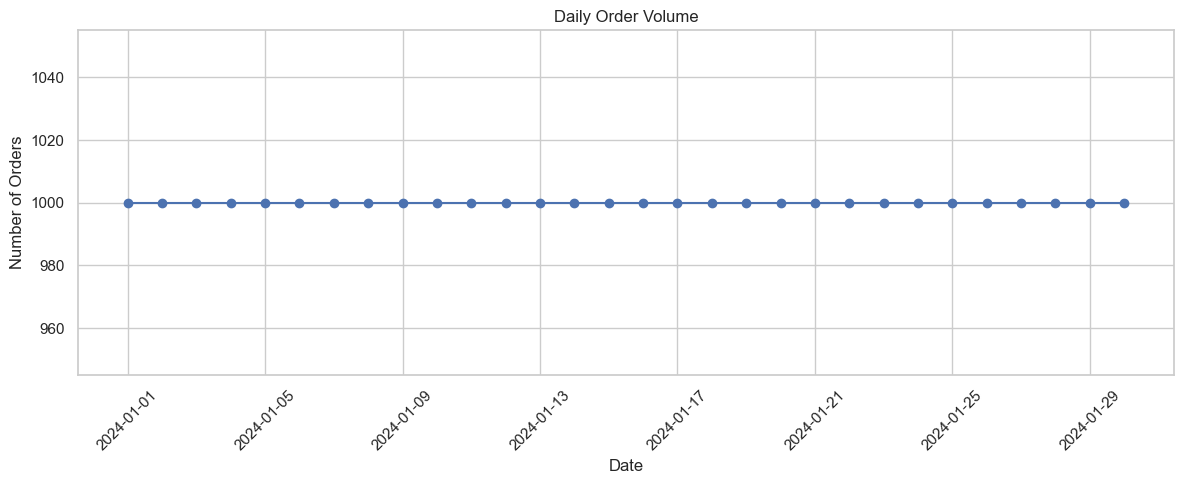

Saved: ..\visuals\charts_from_notebook\daily_orders_trend.png


,order_date,orders_count
0,2024-01-01,1000
1,2024-01-02,1000
2,2024-01-03,1000
3,2024-01-04,1000
4,2024-01-05,1000


In [4]:
# Cell 4: Orders per day

daily_orders = (
    orders_df.groupby("order_date")["order_id"]
    .count()
    .reset_index()
    .rename(columns={"order_id": "orders_count"})
)

plt.figure(figsize=(12, 5))
plt.plot(daily_orders["order_date"], daily_orders["orders_count"], marker="o")
plt.title("Daily Order Volume")
plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()

file_path = OUTPUT_DIR / "daily_orders_trend.png"
plt.savefig(file_path, dpi=300)
plt.show()

print(f"Saved: {file_path}")
daily_orders.head()


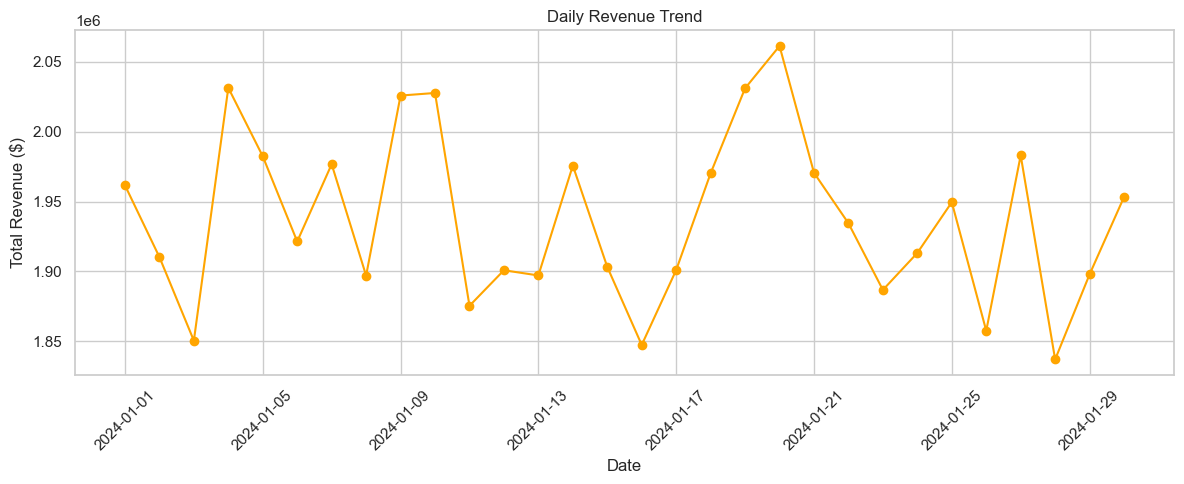

Saved: ..\visuals\charts_from_notebook\daily_revenue_trend.png


,order_date,total_revenue
0,2024-01-01,1961644.06
1,2024-01-02,1910286.65
2,2024-01-03,1850447.76
3,2024-01-04,2031416.51
4,2024-01-05,1982392.97


In [5]:
# Cell 5: Daily revenue trend

daily_revenue = (
    orders_df.groupby("order_date")["order_value"]
    .sum()
    .reset_index()
    .rename(columns={"order_value": "total_revenue"})
)

plt.figure(figsize=(12, 5))
plt.plot(daily_revenue["order_date"], daily_revenue["total_revenue"], color="orange", marker="o")
plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()

file_path = OUTPUT_DIR / "daily_revenue_trend.png"
plt.savefig(file_path, dpi=300)
plt.show()

print(f"Saved: {file_path}")
daily_revenue.head()


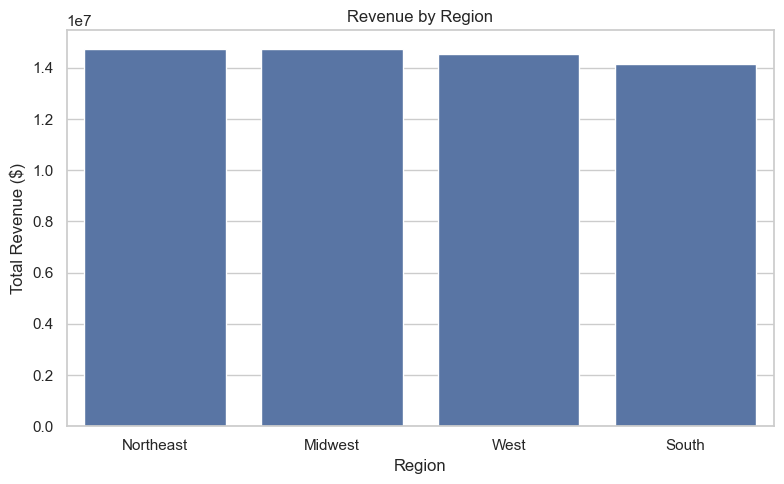

Saved: ..\visuals\charts_from_notebook\region_revenue.png


,customer_region,order_value
1,Northeast,14728282.84
0,Midwest,14718360.24
3,West,14529309.54
2,South,14155360.40


In [6]:
# Cell 6: Revenue by Region

region_revenue = (
    orders_df.groupby("customer_region")["order_value"]
    .sum()
    .reset_index()
    .sort_values("order_value", ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(data=region_revenue, x="customer_region", y="order_value")
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Total Revenue ($)")
plt.tight_layout()

file_path = OUTPUT_DIR / "region_revenue.png"
plt.savefig(file_path, dpi=300)
plt.show()

print(f"Saved: {file_path}")
region_revenue


C:\Users\Charan\AppData\Local\Temp\ipykernel_23688\1798350613.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=priority_counts, x="priority_flag", y="count", palette="viridis")


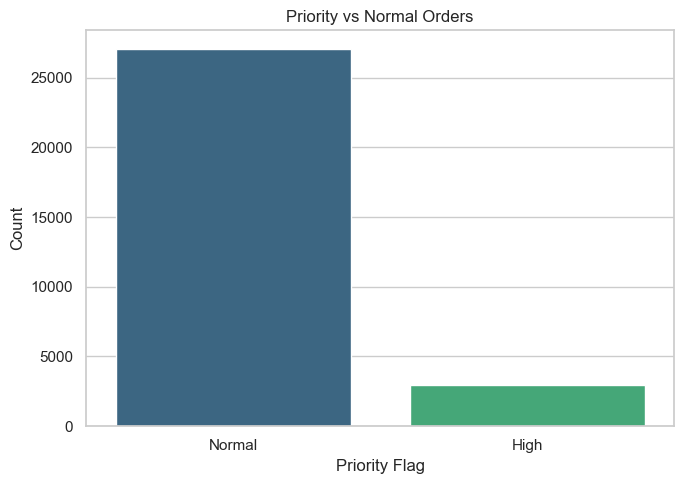

Saved: ..\visuals\charts_from_notebook\priority_orders_distribution.png


,priority_flag,count
0,Normal,27030
1,High,2970


In [7]:
# Cell 7: Priority vs Normal Orders

priority_counts = (
    orders_df["priority_flag"]
    .value_counts()
    .reset_index()
)

priority_counts.columns = ["priority_flag", "count"]

plt.figure(figsize=(7, 5))
sns.barplot(data=priority_counts, x="priority_flag", y="count", palette="viridis")
plt.title("Priority vs Normal Orders")
plt.xlabel("Priority Flag")
plt.ylabel("Count")
plt.tight_layout()

file_path = OUTPUT_DIR / "priority_orders_distribution.png"
plt.savefig(file_path, dpi=300)
plt.show()

print(f"Saved: {file_path}")
priority_counts


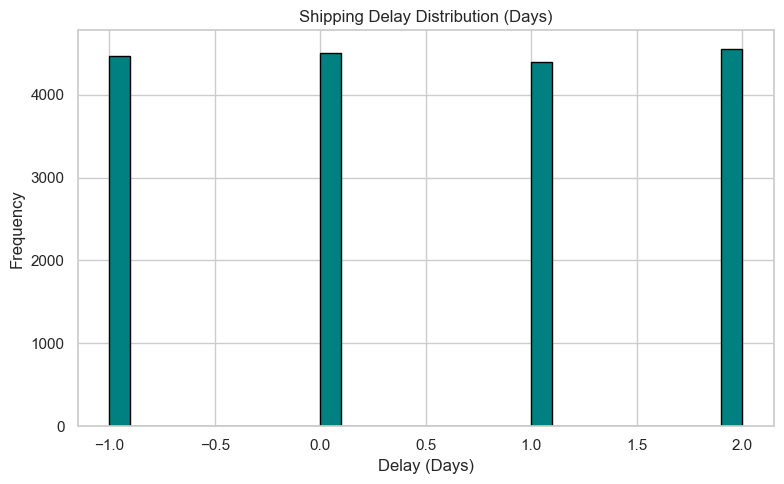

Saved: ..\visuals\charts_from_notebook\shipping_delay_distribution.png


In [8]:
# Cell 8: Shipping delay distribution (in days)

valid_delays = orders_df["shipping_delay_days"].dropna()

plt.figure(figsize=(8, 5))
plt.hist(valid_delays, bins=30, color="teal", edgecolor="black")
plt.title("Shipping Delay Distribution (Days)")
plt.xlabel("Delay (Days)")
plt.ylabel("Frequency")
plt.tight_layout()

file_path = OUTPUT_DIR / "shipping_delay_distribution.png"
plt.savefig(file_path, dpi=300)
plt.show()

print(f"Saved: {file_path}")


C:\Users\Charan\AppData\Local\Temp\ipykernel_23688\3595727363.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_skus, y="sku", x="order_value", palette="magma", orient="h")


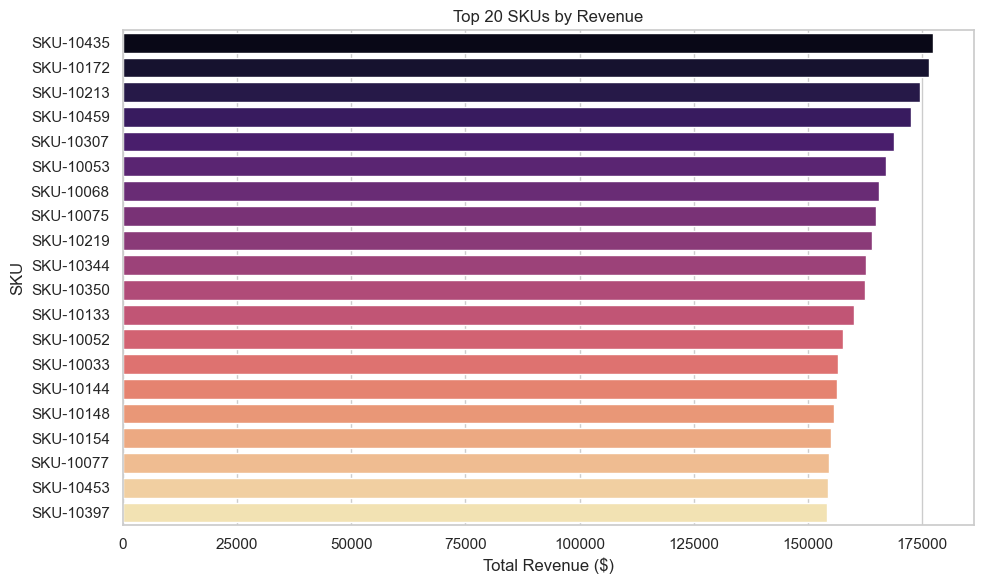

Saved: ..\visuals\charts_from_notebook\top20_skus_revenue.png


,sku,order_value
435,SKU-10435,177473.33
172,SKU-10172,176536.17
213,SKU-10213,174605.28
459,SKU-10459,172475.52
307,SKU-10307,168818.94
53,SKU-10053,167179.71
68,SKU-10068,165566.20
75,SKU-10075,164946.98
219,SKU-10219,163943.37
344,SKU-10344,162634.01


In [9]:
# Cell 9: Top 20 SKUs by revenue

top_skus = (
    orders_df.groupby("sku")["order_value"]
    .sum()
    .reset_index()
    .sort_values("order_value", ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_skus, y="sku", x="order_value", palette="magma", orient="h")
plt.title("Top 20 SKUs by Revenue")
plt.xlabel("Total Revenue ($)")
plt.ylabel("SKU")
plt.tight_layout()

file_path = OUTPUT_DIR / "top20_skus_revenue.png"
plt.savefig(file_path, dpi=300)
plt.show()

print(f"Saved: {file_path}")
top_skus


In [10]:
# Cell 10: Summary metrics for README + Video Script

total_orders = len(orders_df)
total_revenue = orders_df["order_value"].sum()
priority_share = (orders_df["priority_flag"].str.upper().eq("HIGH").mean() * 100).round(2)
avg_delay = orders_df["shipping_delay_days"].mean()

print(f"Total Orders: {total_orders:,}")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"High-Priority Order Share: {priority_share}%")
print(f"Average Shipping Delay: {avg_delay:.2f} days")


Total Orders: 30,000
Total Revenue: $58,131,313.02
High-Priority Order Share: 9.9%
Average Shipping Delay: 0.50 days
